# Phần 3: Phân Tích Benchmark và So Sánh Hiệu Năng

**Người làm:** Thoại

**Mục tiêu:**
- Đọc và chuẩn hóa dữ liệu benchmark đã xuất ra từ `benchmark_results.json`.
- Trình bày bảng số liệu tổng hợp theo phương pháp và loại ma trận.
- Vẽ biểu đồ log-log cho thời gian và sai số để quan sát xu hướng tăng theo kích thước $n$.
- So sánh trực quan giữa các phương pháp trên từng loại ma trận.
- Rút ra nhận xét về tốc độ và độ ổn định số.

**Nguồn dữ liệu:**
- `benchmark_results.json`: dữ liệu có cấu trúc, dùng làm đầu vào chính cho notebook.
- `benchmark.txt`: log terminal giúp đối chiếu kết quả chạy và kiểm tra nhanh quá trình benchmark.


In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# Thiết lập phong cách hiển thị để notebook dễ đọc và đồng nhất
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "font.family": "DejaVu Sans",
    }
)

# Đường dẫn tới file dữ liệu benchmark xuất từ phần 3
BENCHMARK_PATH = Path("benchmark_results.json")

# Thứ tự cố định để trình bày bảng và biểu đồ nhất quán
MATRIX_ORDER = ["random", "spd", "hilbert"]
METHOD_ORDER = [
    "Gauss-Jordan (Part 1)",
    "SVD Decomposition (Part 2)",
    "Gauss-Seidel",
]

# Màu cố định cho từng phương pháp để dễ đối chiếu trên nhiều đồ thị
METHOD_COLORS = {
    "Gauss-Jordan (Part 1)": "#1f77b4",
    "SVD Decomposition (Part 2)": "#d62728",
    "Gauss-Seidel": "#2ca02c",
}

# Nhãn hiển thị đẹp hơn cho từng loại ma trận
MATRIX_LABELS = {
    "random": "Random matrix",
    "spd": "SPD matrix",
    "hilbert": "Hilbert matrix",
}


def load_results(path: Path = BENCHMARK_PATH) -> pd.DataFrame:
    """Đọc file JSON benchmark, kiểm tra cột cần thiết và chuẩn hóa kiểu dữ liệu."""

    # Bước 1: đọc toàn bộ dữ liệu từ file JSON
    with path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    # Bước 2: chuyển sang DataFrame để xử lý bảng dễ hơn
    df = pd.DataFrame(raw_data)
    required_columns = {
        "method",
        "avg_time_sec",
        "avg_relative_error",
        "converged",
        "iterations",
        "success",
        "note",
        "n",
        "matrix_type",
    }

    # Bước 3: xác nhận dữ liệu đầu vào không thiếu cột
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Thiếu cột trong dữ liệu benchmark: {sorted(missing_columns)}")

    # Bước 4: ép kiểu để tránh lỗi khi nhóm, vẽ đồ thị và định dạng bảng
    df = df.copy()
    df["n"] = pd.to_numeric(df["n"], errors="raise").astype(int)
    df["avg_time_sec"] = pd.to_numeric(df["avg_time_sec"], errors="coerce")
    df["avg_relative_error"] = pd.to_numeric(df["avg_relative_error"], errors="coerce")
    df["note"] = df["note"].fillna("")
    df["matrix_type"] = pd.Categorical(df["matrix_type"], categories=MATRIX_ORDER, ordered=True)
    df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)

    # Trả về dữ liệu đã sắp xếp theo loại ma trận, kích thước và phương pháp
    return df.sort_values(["matrix_type", "n", "method"]).reset_index(drop=True)


def format_scientific(value: float) -> str:
    """Định dạng số theo ký hiệu khoa học để bảng sai số gọn và rõ."""

    if pd.isna(value):
        return "-"
    return f"{value:.2e}"


def format_seconds(value: float) -> str:
    """Định dạng thời gian trung bình theo giây."""

    if pd.isna(value):
        return "-"
    return f"{value:.4f}"


# Nạp dữ liệu đã benchmark và lọc riêng các bản ghi thành công
# success_df là nguồn dữ liệu chính cho các bảng và biểu đồ bên dưới
df = load_results()
success_df = df[df["success"]].copy()

print(f"Tổng số bản ghi: {len(df)}")
print(f"Số bản ghi thành công: {len(success_df)}")
print(f"Các loại ma trận: {list(df['matrix_type'].cat.categories)}")
print(f"Các phương pháp: {list(df['method'].cat.categories)}")

display(df.head(9))


Tổng số bản ghi: 45
Số bản ghi thành công: 45
Các loại ma trận: ['random', 'spd', 'hilbert']
Các phương pháp: ['Gauss-Jordan (Part 1)', 'SVD Decomposition (Part 2)', 'Gauss-Seidel']


,method,avg_time_sec,avg_relative_error,converged,iterations,success,note,n,matrix_type
0,Gauss-Jordan (Part 1),0.018059,4.200174e-16,True,NaN,True,,50,random
1,SVD Decomposition (Part 2),0.003963,9.978955e-16,True,NaN,True,,50,random
2,Gauss-Seidel,0.003279,4.058049e-14,True,9.0,True,Hội tụ sau 9 vòng lặp (chéo trội),50,random
3,Gauss-Jordan (Part 1),0.129609,6.249794e-16,True,NaN,True,,100,random
4,SVD Decomposition (Part 2),0.015168,2.124356e-15,True,NaN,True,,100,random
5,Gauss-Seidel,0.011209,2.402194e-15,True,9.0,True,Hội tụ sau 9 vòng lặp (chéo trội),100,random
6,Gauss-Jordan (Part 1),1.013180,8.233254e-16,True,NaN,True,,200,random
7,SVD Decomposition (Part 2),0.054608,2.302704e-15,True,NaN,True,,200,random
8,Gauss-Seidel,0.037545,1.349195e-14,True,8.0,True,Hội tụ sau 8 vòng lặp (chéo trội),200,random


## 3.1 Bảng Số Liệu Tổng Hợp

Bảng dưới đây tóm tắt thời gian chạy trung bình và sai số tương đối trung bình theo từng loại ma trận và phương pháp. Dữ liệu đã được lọc từ `benchmark_results.json` và chỉ giữ các bản ghi thành công.


In [10]:
# Gom dữ liệu theo từng loại ma trận và từng phương pháp
# Ý tưởng: tính trung bình để có một bảng tóm tắt gọn cho báo cáo
summary_table = (
    success_df.groupby(["matrix_type", "method"], observed=True)[["avg_time_sec", "avg_relative_error"]]
    .mean()
    .reset_index()
    .sort_values(["matrix_type", "method"])
)

# Định dạng lại bảng cho dễ đọc trong notebook
summary_table_display = summary_table.copy()
summary_table_display["avg_time_sec"] = summary_table_display["avg_time_sec"].map(format_seconds)
summary_table_display["avg_relative_error"] = summary_table_display["avg_relative_error"].map(format_scientific)
summary_table_display = summary_table_display.rename(
    columns={
        "matrix_type": "Loại ma trận",
        "method": "Phương pháp",
        "avg_time_sec": "Thời gian TB (s)",
        "avg_relative_error": "Sai số TB",
    }
)

display(Markdown("### Bảng tổng hợp theo loại ma trận và phương pháp"))
display(summary_table_display)

# Tìm phương pháp nhanh nhất cho từng cặp (loại ma trận, kích thước n)
# Dùng idxmin để lấy hàng có thời gian nhỏ nhất trong mỗi nhóm
fastest_table = (
    success_df.loc[success_df.groupby(["matrix_type", "n"], observed=True)["avg_time_sec"].idxmin(),
                   ["matrix_type", "n", "method", "avg_time_sec", "avg_relative_error"]]
    .sort_values(["matrix_type", "n"])
    .reset_index(drop=True)
)

fastest_table_display = fastest_table.copy()
fastest_table_display["avg_time_sec"] = fastest_table_display["avg_time_sec"].map(format_seconds)
fastest_table_display["avg_relative_error"] = fastest_table_display["avg_relative_error"].map(format_scientific)
fastest_table_display = fastest_table_display.rename(
    columns={
        "matrix_type": "Loại ma trận",
        "n": "Kích thước n",
        "method": "Phương pháp nhanh nhất",
        "avg_time_sec": "Thời gian TB (s)",
        "avg_relative_error": "Sai số TB",
    }
)

display(Markdown("### Phương pháp nhanh nhất theo từng kích thước"))
display(fastest_table_display)


### Bảng tổng hợp theo loại ma trận và phương pháp

,Loại ma trận,Phương pháp,Thời gian TB (s),Sai số TB
0,random,Gauss-Jordan (Part 1),29.4729,1.00e-15
1,random,SVD Decomposition (Part 2),0.4233,2.27e-15
2,random,Gauss-Seidel,0.2387,1.20e-14
3,spd,Gauss-Jordan (Part 1),28.8473,1.10e-15
4,spd,SVD Decomposition (Part 2),0.4316,6.33e-14
5,spd,Gauss-Seidel,26.5270,9.75e-08
6,hilbert,Gauss-Jordan (Part 1),1.2798,1.88e+03
7,hilbert,SVD Decomposition (Part 2),0.3855,3.66e-07
8,hilbert,Gauss-Seidel,27.5689,8.33e-05


### Phương pháp nhanh nhất theo từng kích thước

,Loại ma trận,Kích thước n,Phương pháp nhanh nhất,Thời gian TB (s),Sai số TB
0,random,50,Gauss-Seidel,0.0033,4.06e-14
1,random,100,Gauss-Seidel,0.0112,2.40e-15
2,random,200,Gauss-Seidel,0.0375,1.35e-14
3,random,500,Gauss-Seidel,0.2642,4.74e-16
4,random,1000,Gauss-Seidel,0.8772,3.17e-15
5,spd,50,SVD Decomposition (Part 2),0.0040,2.02e-14
6,spd,100,SVD Decomposition (Part 2),0.0151,2.65e-14
7,spd,200,SVD Decomposition (Part 2),0.0541,3.93e-14
8,spd,500,SVD Decomposition (Part 2),0.4227,8.08e-14
9,spd,1000,SVD Decomposition (Part 2),1.6620,1.50e-13


### Biểu đồ thời gian chạy


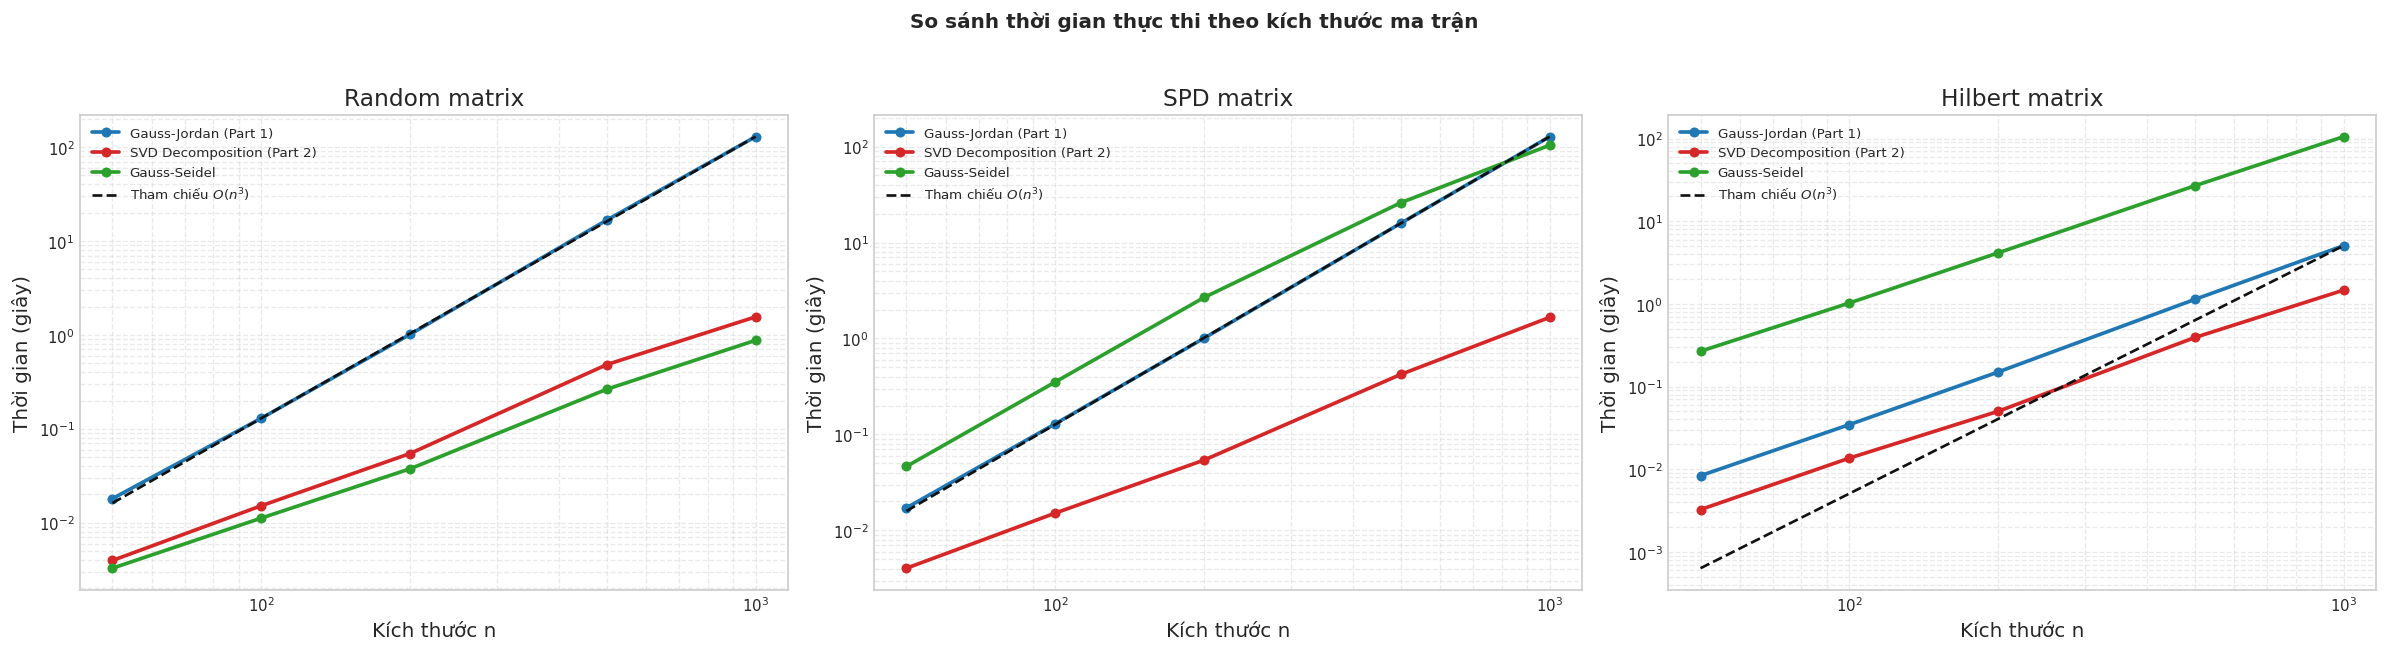

In [11]:
def plot_time_loglog(dataframe: pd.DataFrame) -> None:
    """Vẽ thời gian chạy trung bình theo n trên thang log-log cho từng loại ma trận."""

    # Chia bố cục thành 3 ô, mỗi ô tương ứng với một loại ma trận
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharex=True)
    fig.suptitle("So sánh thời gian thực thi theo kích thước ma trận", fontweight="bold", y=0.98)

    for ax, matrix_type in zip(axes, MATRIX_ORDER):
        subset = dataframe[dataframe["matrix_type"] == matrix_type].copy()

        # Vẽ từng phương pháp trên cùng một trục để so sánh trực tiếp
        for method in METHOD_ORDER:
            method_data = subset[subset["method"] == method].sort_values("n")
            if method_data.empty:
                continue

            ax.loglog(
                method_data["n"],
                method_data["avg_time_sec"],
                marker="o",
                linewidth=2.2,
                markersize=5,
                color=METHOD_COLORS[method],
                label=method,
            )

        # Thêm đường tham chiếu O(n^3) để đối chiếu với lý thuyết
        # Đây là chuẩn trực quan thường dùng cho các phương pháp khử trực tiếp
        reference_source = subset[subset["method"] == "Gauss-Jordan (Part 1)"].sort_values("n")
        if not reference_source.empty:
            anchor_n = reference_source["n"].iloc[-1]
            anchor_time = reference_source["avg_time_sec"].iloc[-1]
            scale_c = anchor_time / (anchor_n ** 3)
            reference_n = reference_source["n"].to_numpy()
            reference_time = scale_c * (reference_n ** 3)
            ax.loglog(
                reference_n,
                reference_time,
                linestyle="--",
                color="#111111",
                linewidth=1.6,
                label=r"Tham chiếu $O(n^3)$",
            )

        ax.set_title(MATRIX_LABELS[matrix_type])
        ax.set_xlabel("Kích thước n")
        ax.set_ylabel("Thời gian (giây)")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=9)
        ax.legend(fontsize=8, frameon=False, loc="best")

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


print("### Biểu đồ thời gian chạy")
plot_time_loglog(success_df)


### Biểu đồ sai số tương đối


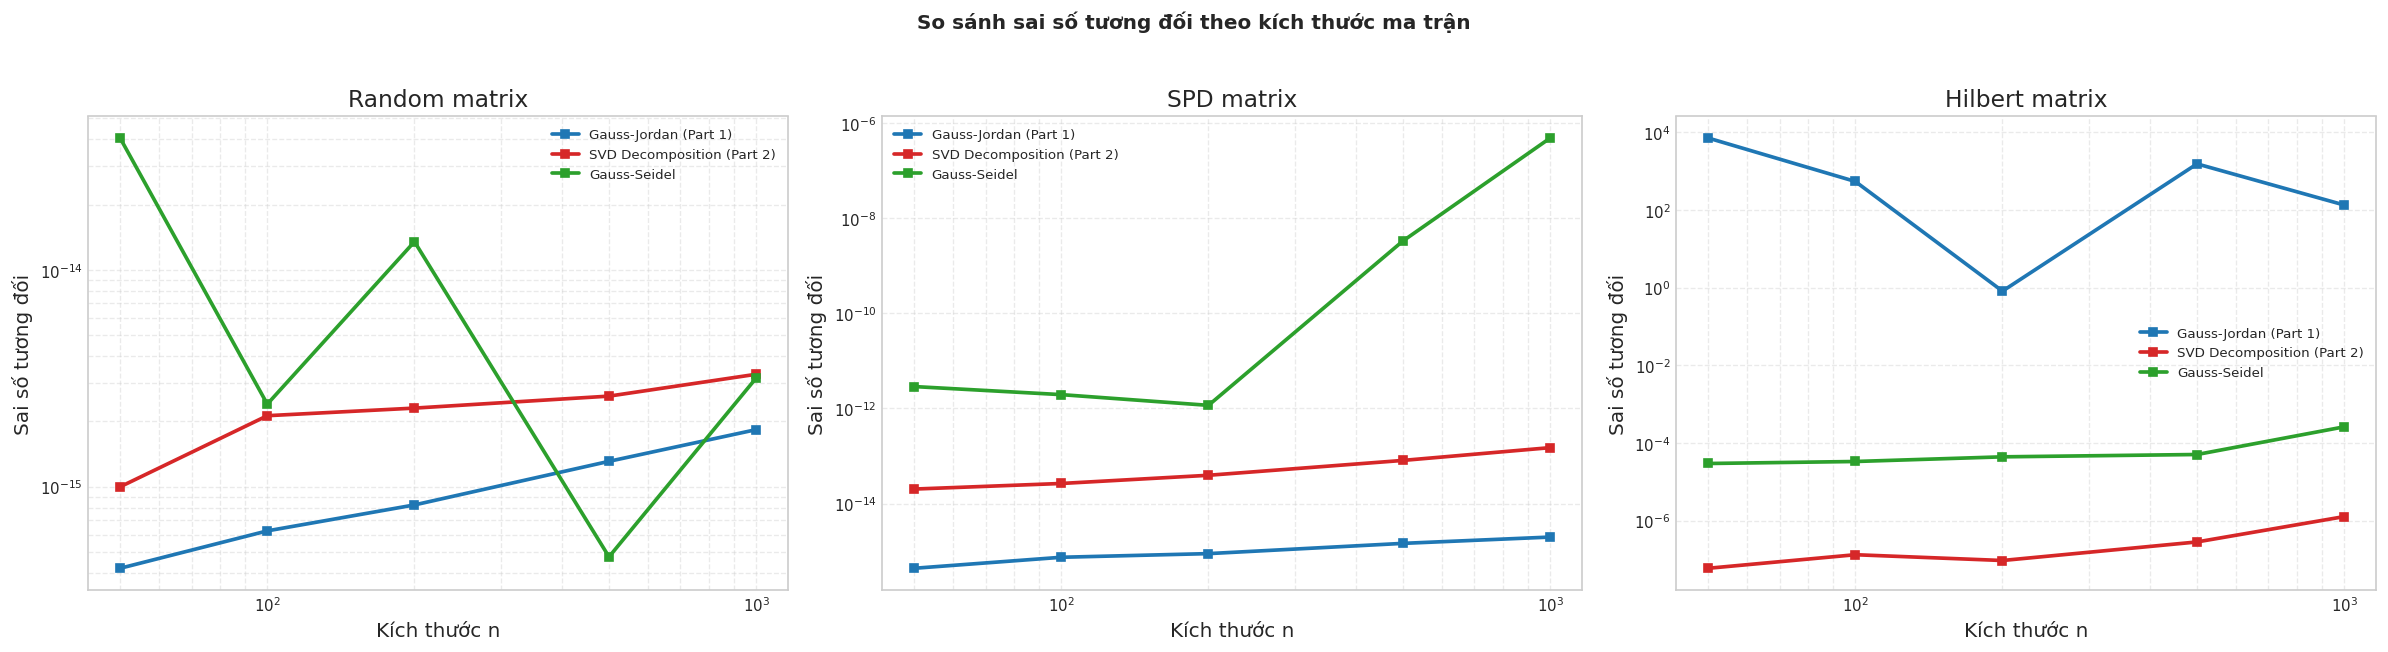

In [12]:
def plot_error_loglog(dataframe: pd.DataFrame) -> None:
    """Vẽ sai số tương đối theo n trên thang log-log cho từng loại ma trận."""

    # Mỗi ô biểu đồ thể hiện một loại ma trận để tránh chồng chéo quá nhiều đường
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharex=True, sharey=False)
    fig.suptitle("So sánh sai số tương đối theo kích thước ma trận", fontweight="bold", y=0.98)

    for ax, matrix_type in zip(axes, MATRIX_ORDER):
        subset = dataframe[dataframe["matrix_type"] == matrix_type].copy()

        # So sánh sai số giữa các phương pháp trên cùng một ô biểu đồ
        for method in METHOD_ORDER:
            method_data = subset[subset["method"] == method].sort_values("n")
            if method_data.empty:
                continue

            ax.loglog(
                method_data["n"],
                method_data["avg_relative_error"],
                marker="s",
                linewidth=2.2,
                markersize=5,
                color=METHOD_COLORS[method],
                label=method,
            )

        ax.set_title(MATRIX_LABELS[matrix_type])
        ax.set_xlabel("Kích thước n")
        ax.set_ylabel("Sai số tương đối")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", which="major", labelsize=9)
        ax.legend(fontsize=8, frameon=False, loc="best")

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


print("### Biểu đồ sai số tương đối")
plot_error_loglog(success_df)


### So sánh trực tiếp tại n = 1000


#### Bảng thời gian chạy (giây)

,Random matrix,SPD matrix,Hilbert matrix
Phương pháp,,,
Gauss-Jordan (Part 1),129.4787,127.1659,5.0721
SVD Decomposition (Part 2),1.5596,1.6620,1.4681
Gauss-Seidel,0.8772,103.5198,105.5527


#### Bảng sai số tương đối

,Random matrix,SPD matrix,Hilbert matrix
Phương pháp,,,
Gauss-Jordan (Part 1),1.83e-15,1.98e-15,1.35e+02
SVD Decomposition (Part 2),3.30e-15,1.50e-13,1.26e-06
Gauss-Seidel,3.17e-15,4.84e-07,2.60e-04


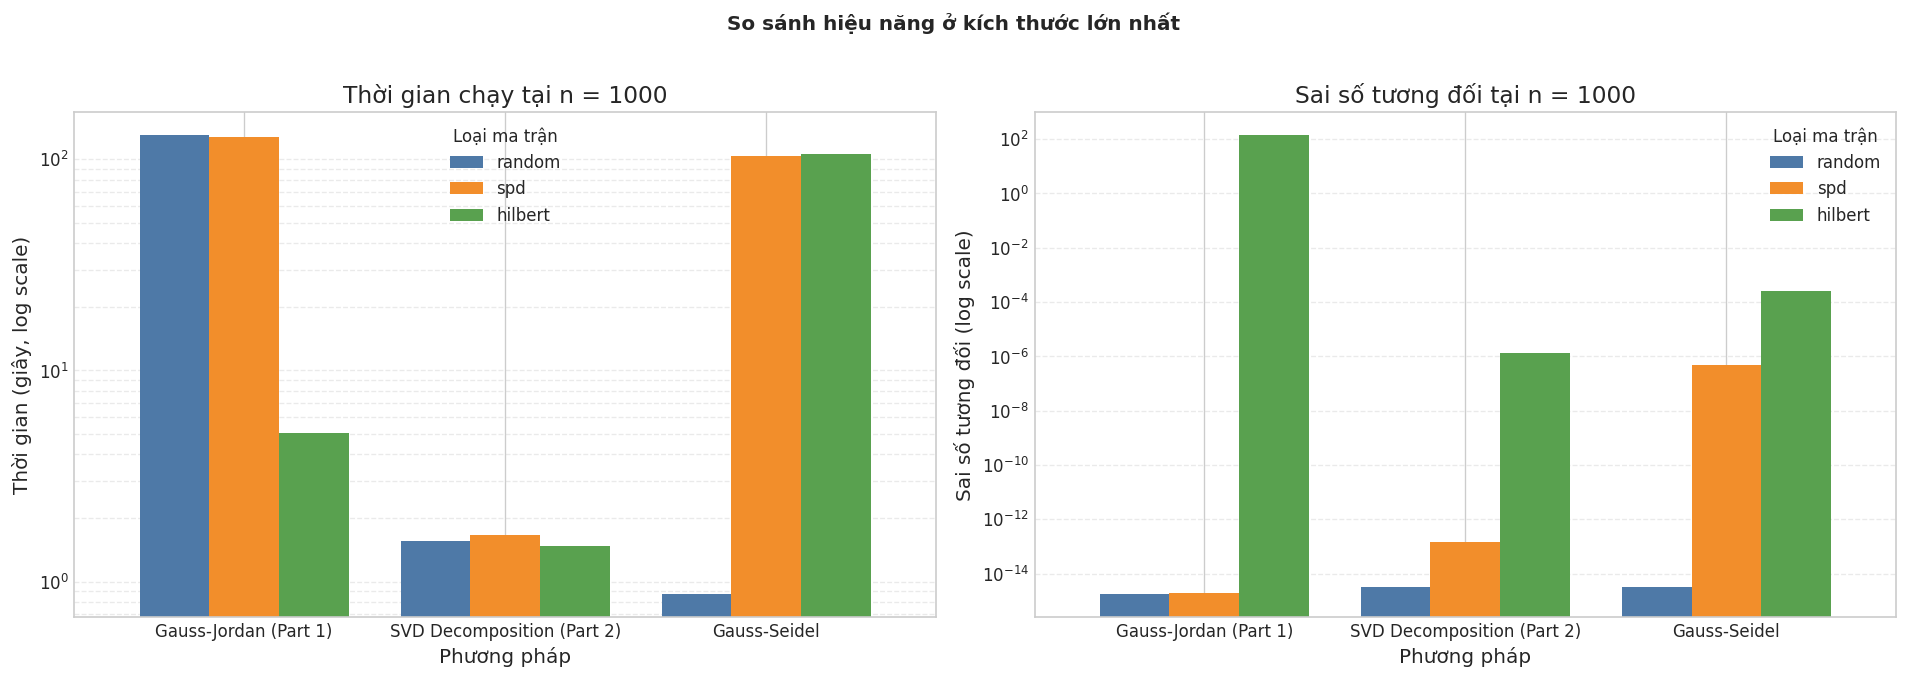

In [ ]:
# Lấy kích thước lớn nhất đã benchmark để so sánh trực tiếp giữa các phương pháp
comparison_n = int(df["n"].max())
comparison_df = success_df[success_df["n"] == comparison_n].copy()

# Chuyển dữ liệu sang dạng bảng chéo: hàng là phương pháp, cột là loại ma trận
comparison_time = (
    comparison_df.pivot(index="method", columns="matrix_type", values="avg_time_sec")
    .reindex(METHOD_ORDER)
    .reindex(columns=MATRIX_ORDER)
)
comparison_error = (
    comparison_df.pivot(index="method", columns="matrix_type", values="avg_relative_error")
    .reindex(METHOD_ORDER)
    .reindex(columns=MATRIX_ORDER)
)

# Định dạng bảng để trình bày trong notebook và báo cáo
comparison_time_display = comparison_time.apply(lambda col: col.map(format_seconds))
comparison_error_display = comparison_error.apply(lambda col: col.map(format_scientific))
comparison_time_display.columns = [MATRIX_LABELS[col] for col in comparison_time_display.columns]
comparison_error_display.columns = [MATRIX_LABELS[col] for col in comparison_error_display.columns]
comparison_time_display.index.name = "Phương pháp"
comparison_error_display.index.name = "Phương pháp"

print(f"### So sánh trực tiếp tại n = {comparison_n}")
display(Markdown("#### Bảng thời gian chạy (giây)"))
display(comparison_time_display)
display(Markdown("#### Bảng sai số tương đối"))
display(comparison_error_display)

# Vẽ hai biểu đồ cột trên thang log để thấy rõ chênh lệch giữa các phương pháp
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
comparison_time.plot(
    kind="bar",
    ax=axes[0],
    color=["#4e79a7", "#f28e2b", "#59a14f"],
    width=0.8,
)
axes[0].set_yscale("log")
axes[0].set_title(f"Thời gian chạy tại n = {comparison_n}")
axes[0].set_xlabel("Phương pháp")
axes[0].set_ylabel("Thời gian (giây, log scale)")
axes[0].grid(True, axis="y", which="both", linestyle="--", alpha=0.4)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Loại ma trận", frameon=False)

comparison_error.plot(
    kind="bar",
    ax=axes[1],
    color=["#4e79a7", "#f28e2b", "#59a14f"],
    width=0.8,
)
axes[1].set_yscale("log")
axes[1].set_title(f"Sai số tương đối tại n = {comparison_n}")
axes[1].set_xlabel("Phương pháp")
axes[1].set_ylabel("Sai số tương đối (log scale)")
axes[1].grid(True, axis="y", which="both", linestyle="--", alpha=0.4)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Loại ma trận", frameon=False)

fig.suptitle("So sánh hiệu năng ở kích thước lớn nhất", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 3.2 Nhận Xét và Kết Luận

Các nhận xét dưới đây được rút ra trực tiếp từ bảng số liệu và các biểu đồ benchmark ở phía trên.

**1. Về thời gian thực thi**
- Với ma trận **random**, phương pháp **Gauss-Seidel** cho thời gian tốt nhất trong bộ dữ liệu này ở hầu hết các kích thước, đặc biệt khi ma trận có tính chéo trội nên hội tụ nhanh. Ở $n = 1000$, thời gian trung bình chỉ khoảng **0.877 s**, nhanh hơn rõ rệt so với Gauss-Jordan.
- Với ma trận **SPD**, **SVD Decomposition** là phương pháp ổn định và nhanh nhất trong ba phương pháp được khảo sát. Ở $n = 1000$, SVD đạt khoảng **1.662 s**, trong khi Gauss-Seidel tăng lên hơn **103 s** do số vòng lặp cần thiết rất lớn.
- Với ma trận **Hilbert**, SVD vẫn giữ thời gian chạy tốt và ổn định hơn so với các phương pháp còn lại. Điều này cho thấy SVD là lựa chọn hợp lý khi bài toán có tính kém điều kiện.
- Trên thang log-log, thời gian của các phương pháp giải trực tiếp tăng theo xu hướng gần với bậc ba, phù hợp với độ phức tạp lý thuyết $\mathcal{O}(n^3)$.

**2. Về sai số và độ ổn định số**
- Trên ma trận **random** và **SPD**, sai số của các phương pháp nhìn chung nằm gần mức máy, tức khoảng $10^{-15}$ đến $10^{-13}$, cho thấy bài toán tương đối ổn định.
- Trên ma trận **Hilbert**, sai số của **Gauss-Jordan** tăng rất mạnh, ví dụ ở $n = 1000$ đạt khoảng **1.35 × $10^{2}$**. Đây là dấu hiệu điển hình của hiện tượng khuếch đại sai số trên bài toán kém điều kiện.
- **SVD Decomposition** cho sai số nhỏ hơn rõ rệt trên Hilbert, dao động khoảng $10^{-8}$ đến $10^{-6}$ tùy kích thước, nên có lợi thế lớn về độ ổn định số.
- **Gauss-Seidel** không phải lúc nào cũng hội tụ; trên Hilbert và một số trường hợp SPD lớn, số vòng lặp đạt ngưỡng tối đa nhưng sai số vẫn còn đáng kể.

**3. Kết luận chung**
- Không có một phương pháp nào tối ưu cho mọi loại ma trận. Kết quả benchmark cho thấy hiệu năng phụ thuộc mạnh vào cấu trúc của ma trận đầu vào.
- Nếu ưu tiên **độ ổn định số**, đặc biệt với ma trận kém điều kiện, **SVD** là lựa chọn an toàn nhất trong bộ thử nghiệm này.
- Nếu ma trận có tính chéo trội và bài toán cho phép dùng phương pháp lặp, **Gauss-Seidel** có thể rất nhanh.
- Nếu mục tiêu là giải thích độ phức tạp và so sánh thực nghiệm với lý thuyết, các kết quả benchmark hiện tại đã phản ánh khá rõ xu hướng $\mathcal{O}(n^3)$ của các phương pháp trực tiếp.
